<a href="https://colab.research.google.com/github/odemircse/NetworkAnalysis/blob/main/04_a_HE_Ethics_Guidelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Remove all user-defined variables
%reset -f
print("All user-defined variables have been removed.")

All user-defined variables have been removed.


In [ ]:
!pip install -q spacy pyvis wordcloud

# Download the large English language model from spaCy (needed for good word vectors)
import spacy.cli
spacy.cli.download("en_core_web_lg")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:



from google.colab import files

# This will prompt you to upload a file from your computer
uploaded = files.upload()

# Print the names of the uploaded files
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving Overall Document2.txt to Overall Document2.txt
User uploaded file "Overall Document2.txt" with length 369263 bytes


                   Word  Count
0                    ai   2091
1               student    404
2             framework    383
3              literacy    352
4             education    307
5                   use    269
6                  tool    227
7      higher education    224
8              learning    217
9                policy    212
10                 data    211
11              teacher    189
12             document    189
13                skill    185
14           competence    169
15           technology    168
16               system    163
17           competency    156
18               report    150
19          development    146
20             research    139
21         intelligence    117
22            guideline    114
23             educator    112
24             strategy    109
25  learning & teaching    109
26             approach    104
27            challenge     92
28             analysis     91
29                 bias     91
30           artificial     88
31      

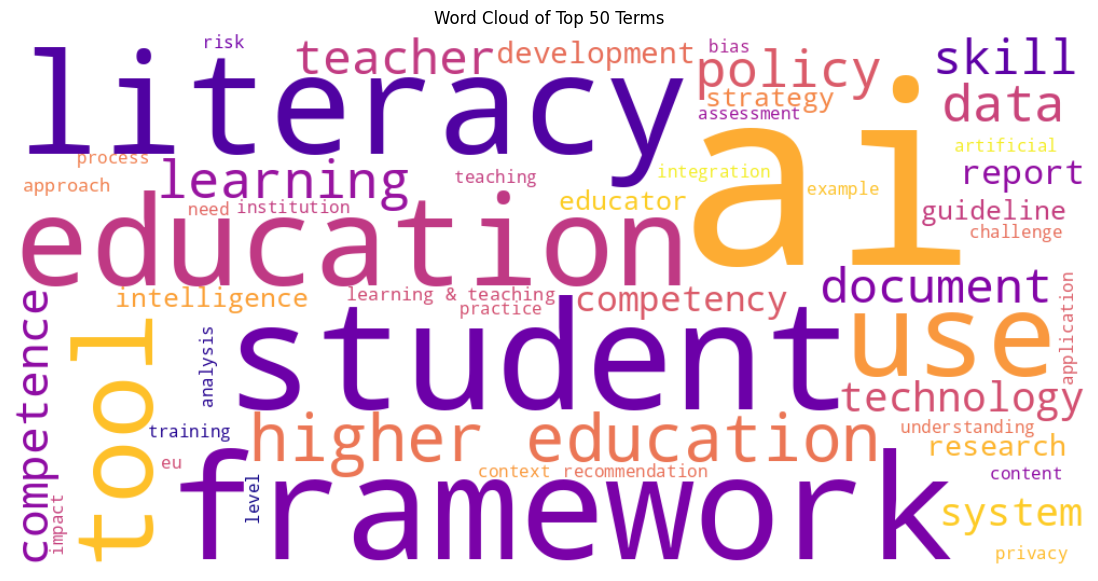

[]


In [ ]:
import spacy
from spacy.matcher import PhraseMatcher
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd


# 1. Load spaCy model
nlp = spacy.load("en_core_web_lg")

# The path to the text file
file_path = "/content/Overall Document2.txt"

# Read the text from the file
try:
    # Try reading with latin-1 encoding first
    with open(file_path, 'r', encoding='latin-1') as f:
        text = f.read()
except UnicodeDecodeError:
    # If latin-1 fails, try another common encoding like cp1252
    try:
        with open(file_path, 'r', encoding='cp1252') as f:
            text = f.read()
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found. Please run Cell 2 or 3 first.")
        text = ""
    except Exception as e:
        print(f"An unexpected error occurred while reading the file with cp1252: {e}")
        text = ""
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please run Cell 2 or 3 first.")
    text = ""
except Exception as e:
    print(f"An unexpected error occurred while reading the file with latin-1: {e}")
    text = ""

# 🧼 Temizlik filtresi
import unicodedata
import re

# 1. Hedefli düzeltme
text = text.replace("studentsõ", "students")

# 2. Yaygın bozuk karakter düzeltmeleri
replacements = {
    "õ": "'", "â€™": "'", "â€“": "-", "â€œ": '"', "â€": '"',
    "Ã¶": "ö", "Ã¼": "ü", "Ã§": "ç", "ÅŸ": "ş", "Ä±": "ı",
    "Ã‡": "Ç", "Ä°": "İ", "Åž": "Ş", "Ã–": "Ö", "Ãœ": "Ü", "Ã": "a"
}
for wrong, correct in replacements.items():
    text = text.replace(wrong, correct)

# 3. Unicode normalize
text = unicodedata.normalize("NFC", text)

# 4. Garip karakterli kelimeleri temizle
text = ' '.join([
    word for word in text.split()
    if all((ord(c) < 128 or c in 'çÇğĞöÖşŞüÜıİ') for c in word)
])

# 5. Fazla boşlukları temizle
text = re.sub(r'\s+', ' ', text).strip()

#Initialize doc
if text:
  doc = nlp(text)

# 2. Concept map for grouping
concept_map = {
    "learning & teaching": ["Learning & Teaching", "Teaching & Learning", "learning and teaching", "teaching and learning"],
    "data": ["Datum", "Data"],
    "higher education": ["Higher Education", "University"],
    "critical thinking":["Critical Thinking"],
    "cognitive skills": ["Cognitive Skills"],
    "research and development": ["Research and Development","r&d"],
    "competency": ["Competence Framework"],
    "high school":["High School"],
    "ai":["gai"]
}


# 3. Build matcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for label, phrases in concept_map.items():
    patterns = [nlp.make_doc(phrase) for phrase in phrases]
    matcher.add(label, patterns)


# 4. Merge matches into single tokens with normalized lemmas
matches = matcher(doc)
spans = [doc[start:end] for _, start, end in matches]
with doc.retokenize() as retokenizer:
    for span in spans:
        label = next((key for key, val in concept_map.items() if span.text.lower() in [v.lower() for v in val]), None)
        if label:
            retokenizer.merge(span, attrs={"LEMMA": label})

# 5. Extract nouns and proper nouns, exclude stopwords/punctuations
excluded_words = {
        "develop", "create", "provide", "ensure", "prepare", "establish", "provide", "prepare", "determine", "learn", "develop", "apply", "educate", "communicate", "mef", "p."
    }
filtered_words = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
    and token.pos_ in {"NOUN", "PROPN"}
    and token.lemma_.lower() not in excluded_words
]

# 6. Get top 50 frequent terms
word_counts = Counter(filtered_words)
most_common = word_counts.most_common(50)
df = pd.DataFrame(most_common, columns=["Word", "Count"])
print(df)

# 7. Generate word cloud  - Burada colormap için viridis yerine turbo,rocket, plasma, magma kullanılabilir
wc = WordCloud(width=1000, height=500, background_color="white", colormap="plasma")
wc.generate_from_frequencies(dict(most_common))

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Top 50 Terms")
plt.show()

from collections import Counter
words = text.split()
weird_words = [word for word in words if any(ord(c) > 127 for c in word)]
print(Counter(weird_words).most_common(10))


/tmp/ipython-input-557924060.py:97: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


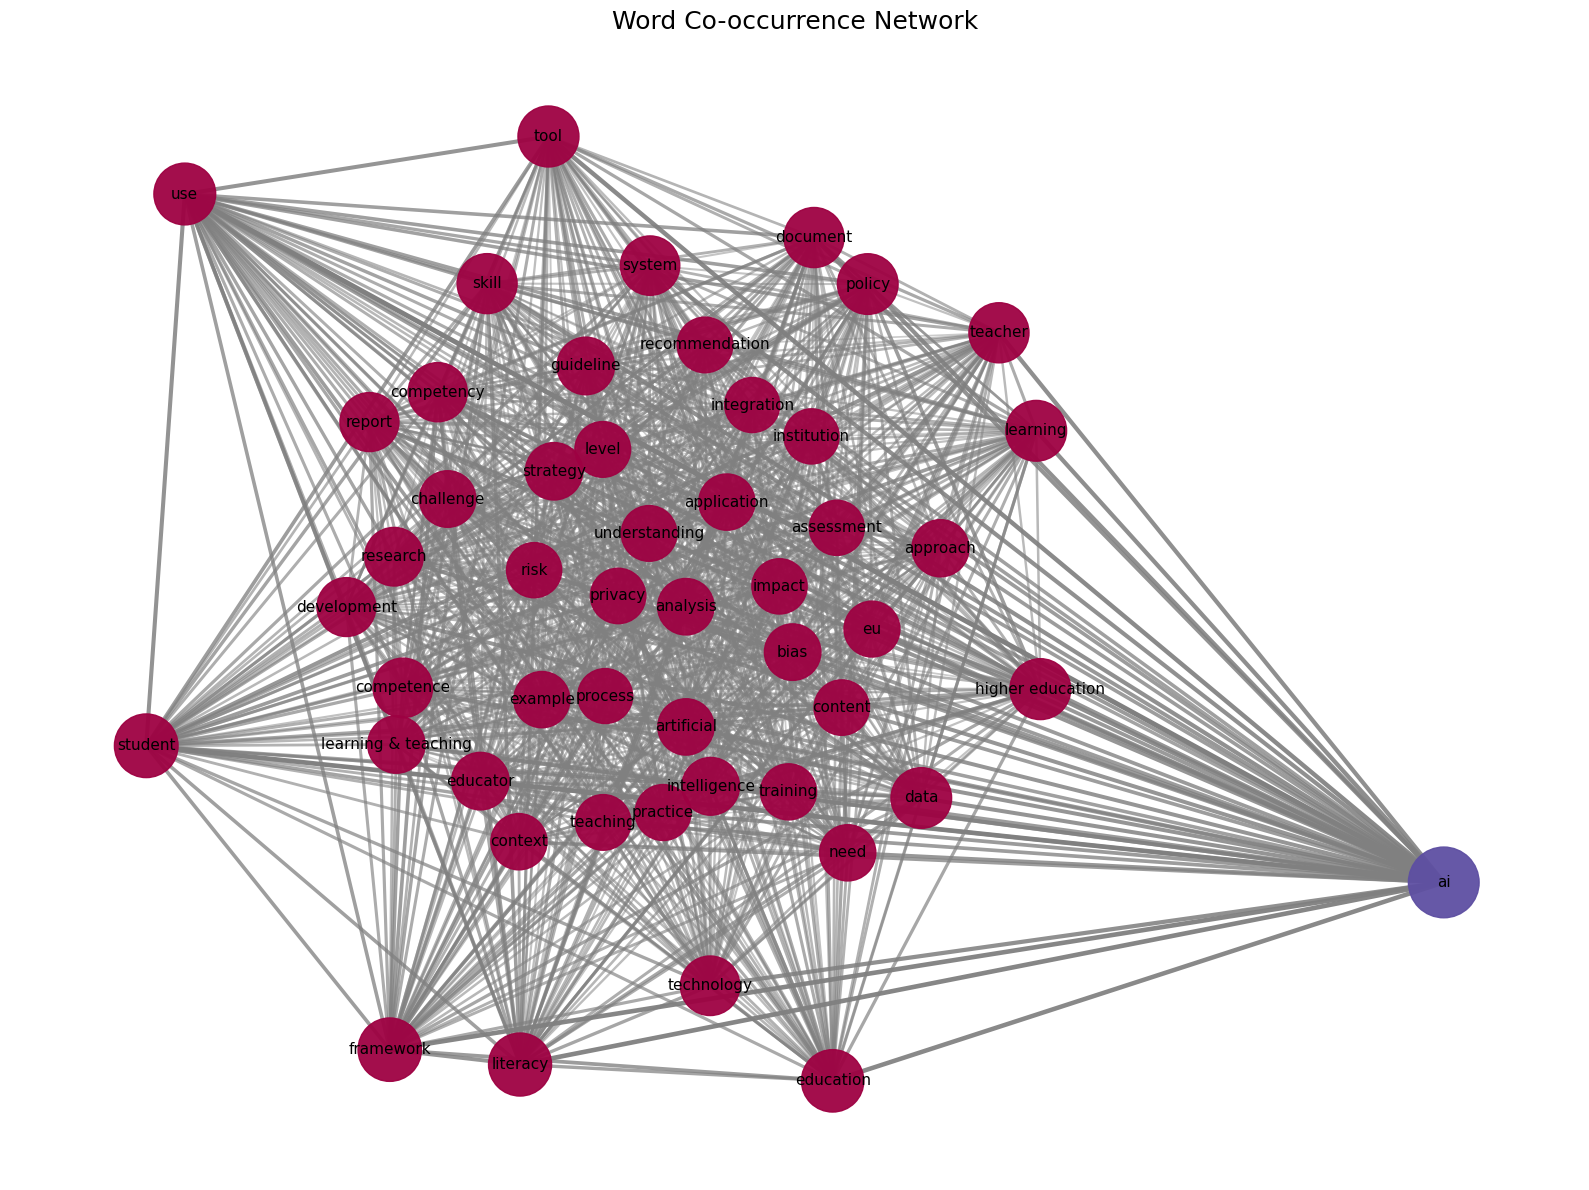

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, ListedColormap, to_hex
from matplotlib import cm
from pyvis.network import Network
from IPython.core.display import display, HTML
from itertools import combinations
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib # Import the top-level matplotlib module

# --- Parameters ---
EDGE_THRESHOLD = 1  # Lowered to allow more connections
NUM_COLOR_BINS = 6  # Number of distinct color steps

# --- Colormap: Spectral segmented into bins ---
cmap = matplotlib.colormaps['Spectral'] # Get the colormap object

# --- Frequency dictionary ---
word_counts_dict = dict(most_common)
counts = list(word_counts_dict.values())
top_words = [word for word, count in most_common]
norm = Normalize(vmin=min(counts), vmax=max(counts))

# --- Build the graph ---
G = nx.Graph()

# Add nodes with binned color mapping
for word, count in most_common:
    bin_index = int(norm(count) * (NUM_COLOR_BINS - 1))
    # Apply the colormap with the bin index
    hex_color = to_hex(cmap(bin_index / (NUM_COLOR_BINS - 1))) # Normalize index for cmap

    G.add_node(word, size=300 + np.log(count + 1) * 300, color=hex_color)


# --- Count co-occurrences of top words ---
edge_counts_words = defaultdict(int)
if text:
    # Assumes 'doc' is available from previous cells (Cell 4)
    # Make sure Cell 4 runs before this cell.
    for sentence in doc.sents:
        words_in_sentence = {
            token.lemma_.lower() for token in sentence if token.lemma_.lower() in top_words
        }
        if len(words_in_sentence) > 1:
            for pair in combinations(sorted(words_in_sentence), 2):
                edge_counts_words[pair] += 1


# Re-add nodes with binned color mapping (this block seems redundant, keeping for now)
# Note: Node attributes (like color) are updated if the node already exists.
for word, count in most_common:
    bin_index = int(norm(count) * (NUM_COLOR_BINS - 1))
    # Apply the colormap with the bin index
    hex_color = to_hex(cmap(bin_index / (NUM_COLOR_BINS - 1))) # Normalize index for cmap
    G.add_node(word, size=300 + np.log(count + 1) * 300, color=hex_color)

# Re-define these variables (they should be available from previous cells, keeping for now)
top_words = [word for word, count in most_common]
word_counts_dict = dict(most_common)
counts = list(word_counts_dict.values())


# Add edges with co-occurrence weights
for (w1, w2), cooc in edge_counts_words.items():
    if cooc >= EDGE_THRESHOLD:
        G.add_edge(w1, w2, weight=0.5 + np.log(cooc + 1))


# --- Use Kamada-Kawai layout with increased scale ---
plt.figure(figsize=(16, 12))  # Bigger canvas
pos = nx.kamada_kawai_layout(G, scale=5)  # More space between nodes

# --- Prepare draw parameters ---
node_sizes = [G.nodes[n]['size'] for n in G.nodes]
node_colors = [G.nodes[n]['color'] for n in G.nodes]
# edge_widths = [G[u][v]['weight'] for u, v in G.edges] # This line is not used


# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.95)

# Improved edge drawing (like World Economic Forum map)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
if edge_weights: # Avoid division by zero if no edges exist
    max_weight = max(edge_weights)
    # Scale edge widths based on weight
    edge_widths = [0.5 + 3 * (w / max_weight) for w in edge_weights]
    # Scale edge alphas based on weight
    edge_alphas = [0.2 + 0.8 * (w / max_weight) for w in edge_weights]

    for (edge, width, alpha) in zip(G.edges, edge_widths, edge_alphas):
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[edge],
            width=width,
            edge_color='gray',
            alpha=alpha,
            connectionstyle='arc3,rad=0.15',
            arrows=False  # Arrows were causing issues with curved edges in previous attempts
        )
else:
    # Draw edges with default parameters if no edges exist
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, connectionstyle='arc3,rad=0.15', arrows=False)


# Draw labels
nx.draw_networkx_labels(G, pos, font_size=11, font_color='black')

plt.title("Word Co-occurrence Network", fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.savefig("word_network_curved_edges.svg", format="svg")
plt.show()

In [ ]:
pip install adjustText


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors
import pandas as pd
import community as community_louvain  # pip install python-louvain if missing

# === Renkleri üret (rank-based, Spectral) ===
from matplotlib import colormaps, colors
import numpy as np

nodes = list(G.nodes())

# HATA NEDENİ: word_counts_dict'te olmayan düğümler vardı.
# ÇÖZÜM: .get() ile güvenli eriş; yoksa degree değerini kullan.
vals = np.array([word_counts_dict.get(n, G.degree(n)) for n in nodes])

# 0..1 arası sıralama ölçeği → renkler tüm aralığa yayılır
ranks = vals.argsort().argsort().astype(float)
ranks /= max(len(ranks) - 1, 1)

cmap = colormaps['Spectral']        # çok renkli palet (istersen 'Set2' pastel)
quantile_node_colors = [colors.to_hex(cmap(r)) for r in ranks]
# === /Renkler ===


data düğümünün mevcut pozisyonu: [-0.41245153 -0.71151251]
data düğümünün yeni pozisyonu: (np.float64(-0.39245152740639094), np.float64(-0.7115125149111939))


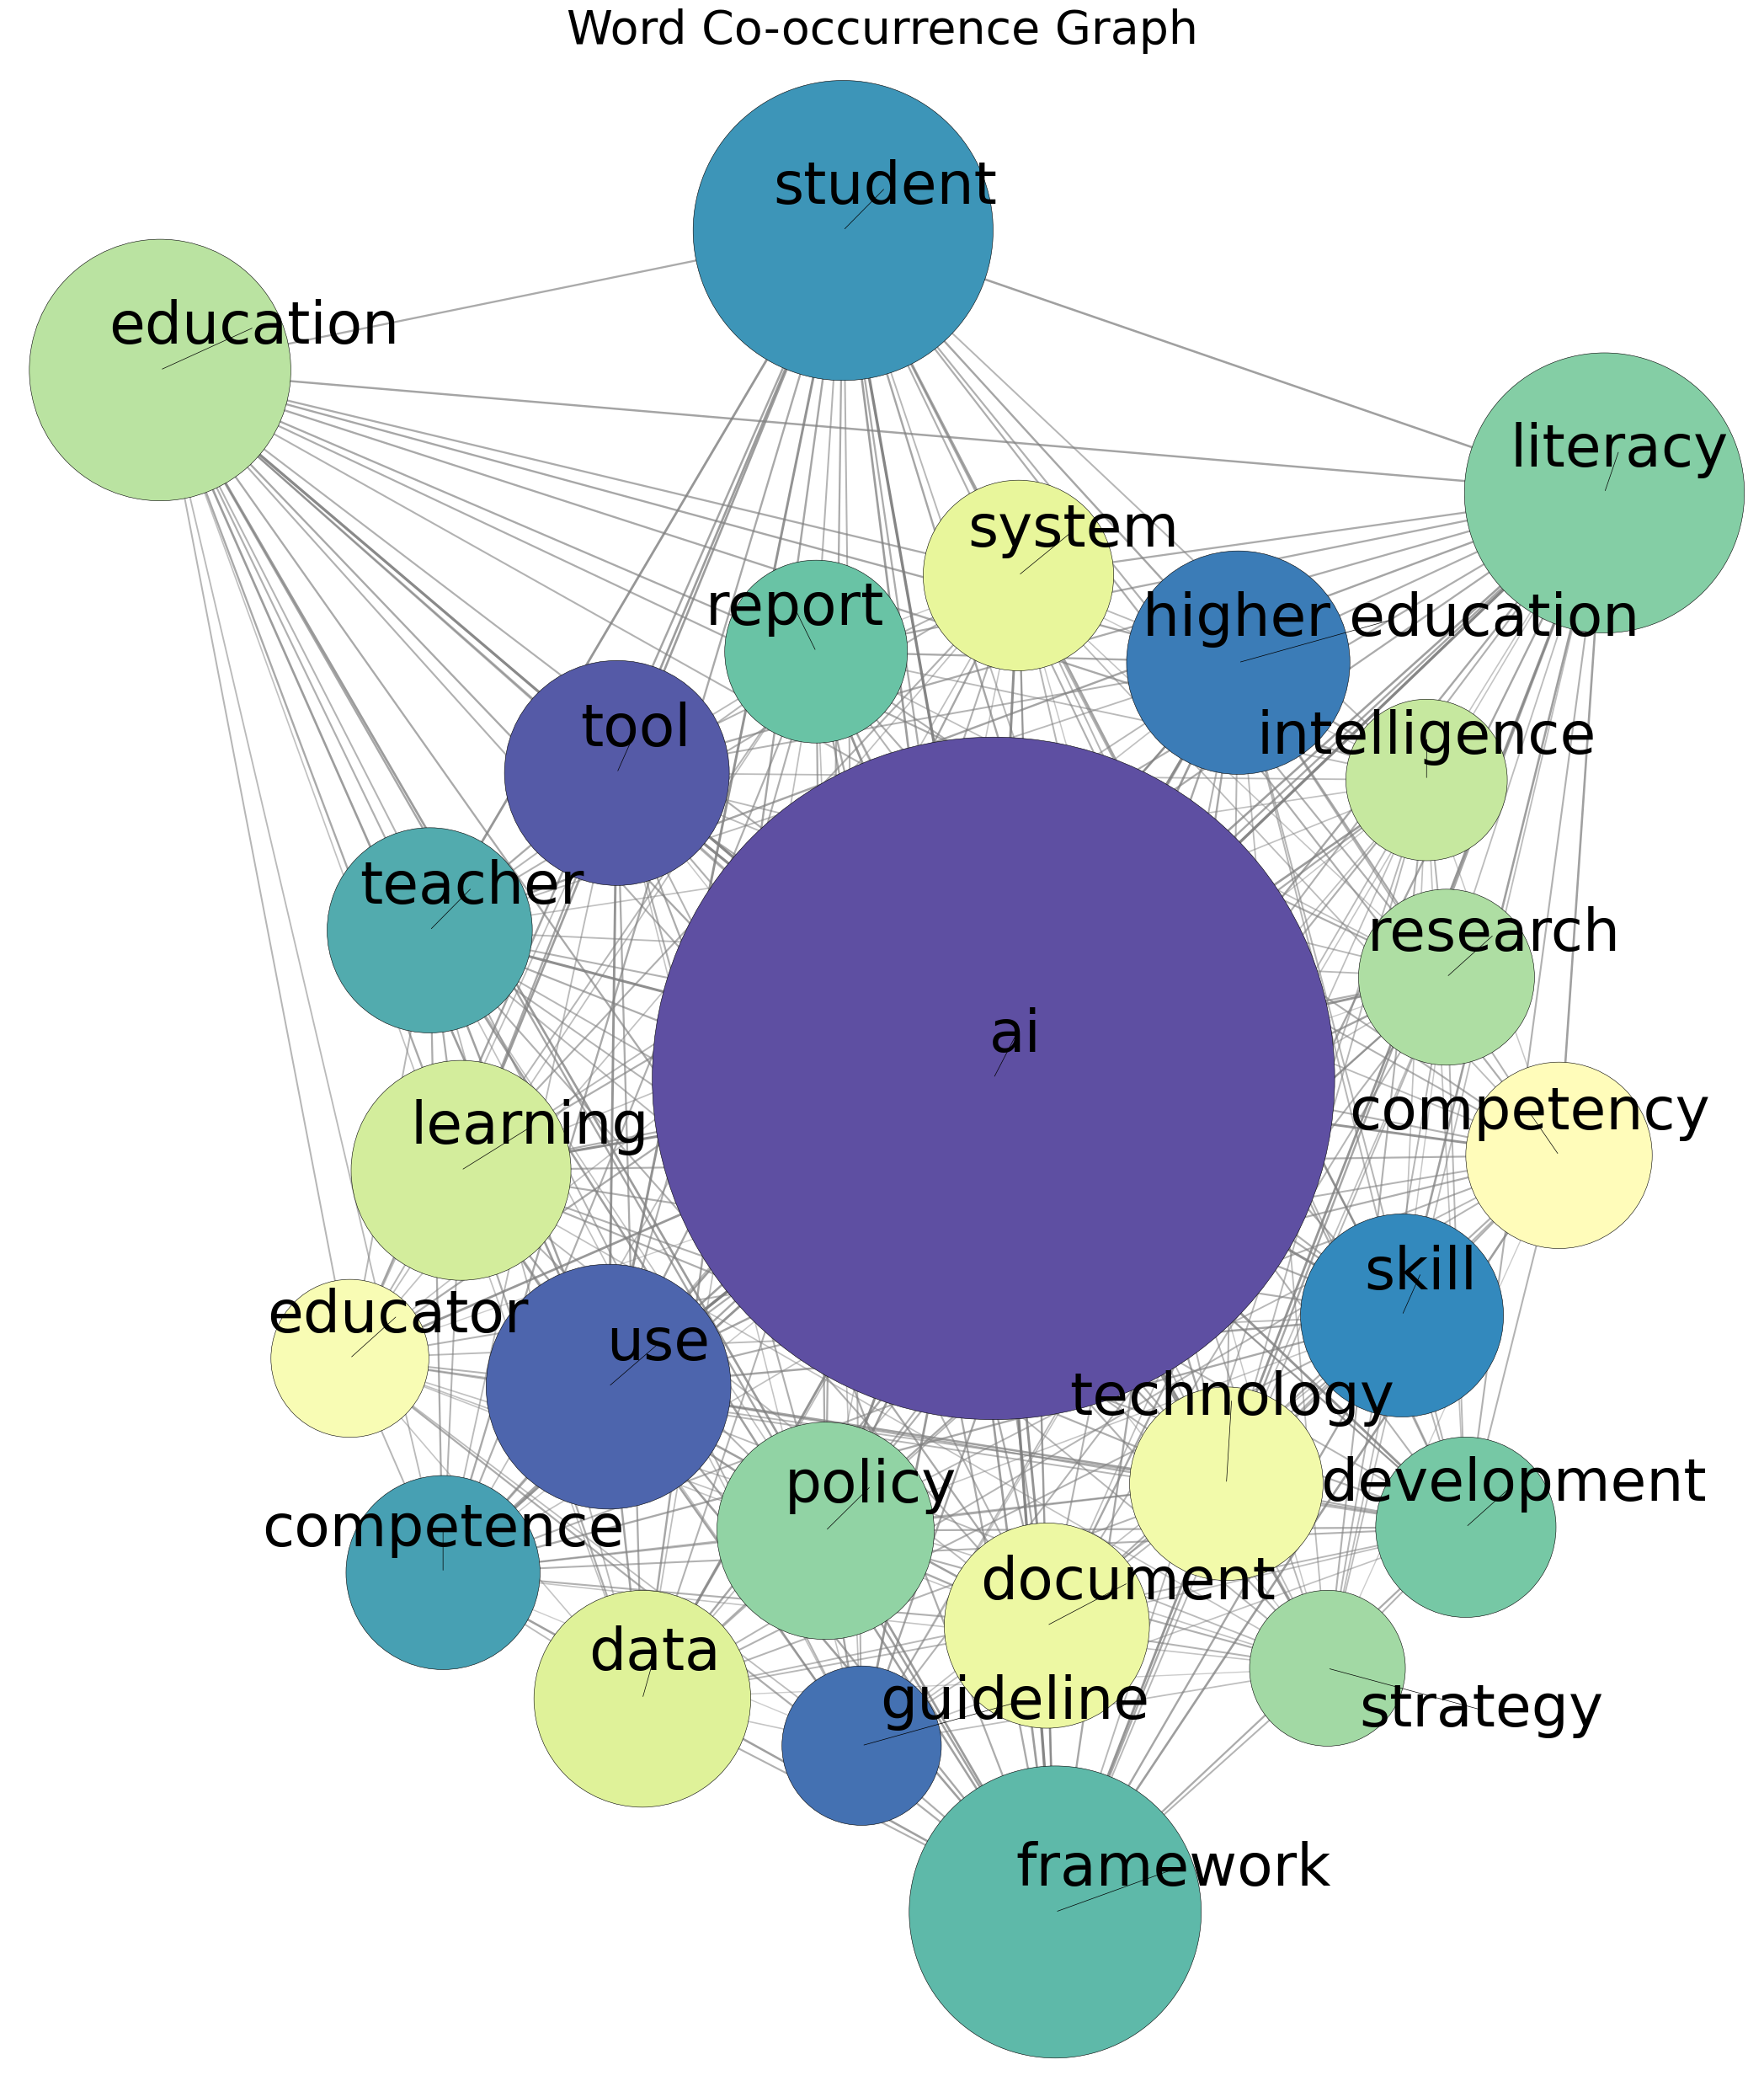

In [ ]:
!pip install adjustText
from adjustText import adjust_text
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from adjustText import adjust_text

# --- Threshold filtering ---
THRESHOLD = 1.5
G_filtered = nx.Graph()
for u, v, d in G.edges(data=True):
    if d['weight'] >= THRESHOLD:
        G_filtered.add_edge(u, v, **d)
G_filtered.add_nodes_from(G.nodes(data=True))  # retain node attributes

# --- Sadece en yüksek 25 kelimeyi tut ---
TOP_N = 25
top_nodes = [n for n, c in sorted(word_counts_dict.items(), key=lambda kv: kv[1], reverse=True)[:TOP_N]]
G_filtered = G_filtered.subgraph(top_nodes).copy()

# --- Layout using Kamada-Kawai (for less overlap) ---
#pos = nx.kamada_kawai_layout(G_filtered)
pos = nx.spring_layout(
    G_filtered,
    seed=85,
    k=5,          # more spacing between nodes
    iterations=500  # more precision
)

if 'data' in pos:
    print(f"data düğümünün mevcut pozisyonu: {pos['data']}")

if 'confidentiality' in pos:
    print(f"confidentiality düğümünün mevcut pozisyonu: {pos['confidentiality']}")
if 'transparency' in pos:
    print(f"transparency düğümünün mevcut pozisyonu: {pos['transparency']}")

target_node = 'confidentiality'
move_up_amount = -0.2  # Bu değeri ihtiyacınıza göre ayarlayın

# Düğümün pos sözlüğünde var olduğundan emin olun
if target_node in pos:
    current_x, current_y = pos[target_node]
    new_y = current_y + move_up_amount
    pos[target_node] = (current_x, new_y)
    print(f"{target_node} düğümünün yeni pozisyonu: {pos[target_node]}")

target_node_2 = 'data'
move_left_amount = -0.02
if target_node_2 in pos:
    current_x, current_y = pos[target_node_2]
    new_x = current_x - move_left_amount
    pos[target_node_2] = (new_x, current_y)
    print(f"{target_node_2} düğümünün yeni pozisyonu: {pos[target_node_2]}")

target_node_3 = 'transparency'
move_up_amount = 0.35  # Bu değeri ihtiyacınıza göre ayarlayın
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    pos[target_node_3] = (current_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'diligence'
move_up_amount = -0.2  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = 0.02
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'contribution'
move_up_amount = 0.1  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = 0.0
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'production'
move_up_amount = 0.0  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = -0.04
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'work'
move_up_amount = 0.05  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = -0.03
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'content'
move_up_amount = 0.02  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = 0.02
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'scientific'
move_up_amount = 0.03  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = -0.03
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'researcher'
move_up_amount = 0.02  # Bu değeri ihtiyacınıza göre ayarlayın
move_left_amount = 0.02
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_left_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

# --- 3D node drawing ---
def draw_3d_nodes(ax, pos, node_sizes, node_colors):
    for (node, (x, y), size, color) in zip(G_filtered.nodes(), pos.values(), node_sizes, node_colors):
        r = np.sqrt(size) / 500
        circle = plt.Circle((x, y), r, color=color, ec='black', lw=0.4, zorder=2)
        ax.add_patch(circle)

def draw_halos(ax, pos, nodes, color='lightgray', alpha=0.5, size=1000):
    for node in nodes:
        if node in pos:
            x, y = pos[node]
            halo = plt.Circle((x, y), np.sqrt(size) / 400, color=color, alpha=alpha, zorder=1)
            ax.add_patch(halo)

# --- NEW: Overlap resolver (düğümler üst üste binmesin) ---
def resolve_overlaps(pos, radii, padding=0.05, max_iter=1200):
    """
    pos: {node: (x,y)}
    radii: {node: r}  # çizimde kullanılan daire yarıçapı (r = sqrt(size)/500)
    padding: düğümler arasında bırakılacak ek boşluk
    """
    nodes = list(pos.keys())
    for _ in range(max_iter):
        moved = False
        for i in range(len(nodes)):
            n1 = nodes[i]; x1, y1 = pos[n1]; r1 = radii.get(n1, 0.0)
            for j in range(i+1, len(nodes)):
                n2 = nodes[j]; x2, y2 = pos[n2]; r2 = radii.get(n2, 0.0)
                dx = x2 - x1; dy = y2 - y1
                dist = (dx*dx + dy*dy) ** 0.5 + 1e-12
                min_dist = r1 + r2 + padding
                if dist < min_dist:
                    push = 0.5 * (min_dist - dist) / dist
                    pos[n1] = (x1 - dx * push, y1 - dy * push)
                    pos[n2] = (x2 + dx * push, y2 + dy * push)
                    moved = True
        if not moved:
            break
    return pos

# --- Node size ---
node_sizes = [word_counts_dict[n] * 40 for n in G_filtered.nodes()]

# --- Central nodes logic ---
central_nodes = sorted(word_counts_dict.items(), key=lambda x: x[1], reverse=True)[:5]
central_node_names = [n for n, _ in central_nodes]

# Push central nodes outward from graph center
center_x = np.mean([x for x, y in pos.values()])
center_y = np.mean([y for x, y in pos.values()])
for node in central_node_names:
    if node in pos:
        x, y = pos[node]
        dx = x - center_x
        dy = y - center_y
        factor = 2.8
        pos[node] = (x + dx * factor, y + dy * factor)

# --- NEW: Çakışma çözümünü, tüm kaydırmalardan SONRA çağır ---
radii = {n: np.sqrt(word_counts_dict[n] * 40) / 500.0 for n in G_filtered.nodes()}  # r = sqrt(size)/500
pos = resolve_overlaps(pos, radii, padding=0.05, max_iter=1200)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(25, 25))
ax.set_aspect('equal')
ax.axis('off')

# --- Edges ---
edge_weights = [G_filtered[u][v]['weight'] for u, v in G_filtered.edges]
max_weight = max(edge_weights)
edge_widths = [0.5 + 2 * (w / max_weight) for w in edge_weights]
edge_alphas = [0.2 + 0.8 * (w / max_weight) for w in edge_weights]

for (edge, width, alpha) in zip(G_filtered.edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(G_filtered, pos, edgelist=[edge], width=width,
                           edge_color='gray', alpha=alpha, ax=ax)

# --- Halos ---
draw_halos(ax, pos, G_filtered.nodes(), color='white', alpha=0.1)

# --- 3D-look Nodes ---
draw_3d_nodes(ax, pos, node_sizes, quantile_node_colors)

# --- Smart labels using adjustText (KEEP ONLY THIS) ---
texts = []
for node, (x, y) in pos.items():
    texts.append(ax.text(x, y, node, fontsize=50, ha='center', va='bottom'))

adjust_text(
    texts,
    ax=ax,
    expand_text=(1.3, 1.4),
    force_text=2.0,
    arrowprops=dict(arrowstyle="-", lw=0.5),
    lim=1000
)

# --- Title & Save ---
plt.title("Word Co-occurrence Graph", fontsize=40)
plt.tight_layout()
plt.savefig("word_network_kamada_adjusted.png", dpi=300)
plt.show()


In [ ]:
# --- Calculate Semantic Similarity between Top Words ---
print("\n--- Semantic Similarity Analysis ---")
similarity_pairs = []
top_word_docs = [nlp(word) for word, count in most_common]

if len(top_word_docs) > 1:
    for doc1, doc2 in combinations(top_word_docs, 2):
        # Ensure words have vectors before comparing
        if doc1.has_vector and doc2.has_vector:
            similarity = doc1.similarity(doc2)
            similarity_pairs.append((doc1.text, doc2.text, similarity))

# Create a DataFrame for easy sorting
similarity_df = pd.DataFrame(similarity_pairs, columns=['Word 1', 'Word 2', 'Similarity'])

# --- Display Most CLOSE Words ---
print("\n--- Top 10 Most Semantically CLOSE Word Pairs ---")
most_similar_df = similarity_df.sort_values(by='Similarity', ascending=False).head(10)
print(most_similar_df.to_string(index=False))

# --- Display Most DISTANT Words ---
print("\n--- Top 10 Most Semantically DISTANT Word Pairs ---")
# We filter out scores of 0 which can mean out-of-vocabulary
most_distant_df = similarity_df[similarity_df['Similarity'] > 0].sort_values(by='Similarity', ascending=True).head(10)
print(most_distant_df.to_string(index=False))


--- Semantic Similarity Analysis ---

--- Top 10 Most Semantically CLOSE Word Pairs ---
             Word 1              Word 2  Similarity
          education    higher education    0.870285
           learning learning & teaching    0.869318
learning & teaching            teaching    0.868311
           learning            teaching    0.806151
         competence          competency    0.805696
            student             teacher    0.741736
           literacy           education    0.739135
          education            teaching    0.731041
            teacher            teaching    0.729706
          education            learning    0.699891

--- Top 10 Most Semantically DISTANT Word Pairs ---
      Word 1      Word 2  Similarity
          ai  competency    0.005032
          ai integration    0.007690
intelligence          eu    0.008008
        tool          eu    0.009431
          ai    literacy    0.014320
    literacy          eu    0.015601
     student          eu   

In [ ]:
from collections import defaultdict
from spacy.matcher import PhraseMatcher

# --- 1. DEFINE YOUR RISKS (Case-Insensitive Matching) ---
skills = [
    {
        "category": "Cognitive Skills",
        "skills": [
            "Analytical thinking",
            "Creative thinking",
            "Systems thinking",
            "Multilingualism",
            "Reading & writing",
            "Mathematics",
            "Mathematical infrastructure",
            "Mathematical modeling",
            "Mathematical instructions"
        ]
    },
    {
        "category": "Self-efficacy Skills",
        "skills": [
            "Resilience",
            "Flexibility",
            "Agility",
            "Motivation",
            "Self-awareness",
            "Curiosity",
            "Lifelong learning",
            "Dependability",
            "Attention to detail"
        ]
    },
    {
        "category": "Working with Others",
        "skills": [
            "Leadership",
            "Social influence",
            "Empathy",
            "Active listening",
            "Teaching",
            "Mentoring"
        ]
    },
    {
        "category": "Technology Skills",
        "skills": [
            "Technological literacy",
            "AI",
            "AI literacy",
            "AI knowledge",
            "Big Data",
            "Data analysis",
            "Interpretation",
            "Data governance",
            "Networks",
            "Network administration",
            "Cybersecurity",
            "Design",
            "User experience",
            "Programming",
            "Coding",
            "Software development"
        ]
    },
    {
        "category": "Management Skills",
        "skills": [
            "Talent management",
            "Resource management",
            "Operations management",
            "Quality control"
        ]
    },
    {
        "category": "Engagement Skills",
        "skills": [
            "Service orientation",
            "Customer service",
            "Communication",
            "Conflict resolution",
            "Problem-solving",
            "Marketing & media",
            "Marketing",
            "Media",
            "Digital communication",
            "Content creation",
            "Persuasion",
            "Environmental stewardship",
            "Sustainability",
            "Global citizenship",
            "Cultural awareness",
            "Ethics",
            "Civic responsibility"
        ]
    },
    {
        "category": "Physical Abilities",
        "skills": [
            "Manual dexterity",
            "Endurance",
            "Precision",
            "Sensory-processing abilities"
        ]
    }
]


# attr='LOWER' makes the matching case-insensitive. "Debt" and "debt" will both match.
matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
# Corrected: Iterate through the 'skills' list within each dictionary
patterns = []
for category_data in skills:
    for skill_name in category_data["skills"]:
        patterns.append(nlp.make_doc(skill_name))

matcher.add("RISKS", patterns)

node_counts_risk = defaultdict(int)
edge_counts_risk = defaultdict(int)

# --- 2. PROCESS TEXT TO FIND RISK NODES AND EDGES ---
if text:
    doc = nlp(text)
    # The 'doc' object is reused from Cell 4, no need to re-process.

    matches = matcher(doc)
    # Store results in a case-normalized way
    for match_id, start, end in matches:
        node_label = doc[start:end].text.lower().title() # Normalize to Title Case
        node_counts_risk[node_label] += 1

    for sentence in doc.sents:
        sentence_risks = set()
        sentence_matches = matcher(sentence)
        for match_id, start, end in sentence_matches:
            sentence_risks.add(sentence[start:end].text.lower().title()) # Normalize

        if len(sentence_risks) > 1:
            for pair in combinations(sorted(list(sentence_risks)), 2):
                edge_counts_risk[pair] += 1

# --- 3. PREPARE DATA FOR RISK VISUALIZATION ---
nodes_data_risk = [{'id': label, 'label': label, 'size': 10 + count * 5, 'title': f'Mentions: {count}'}
                   for label, count in node_counts_risk.items()]

edges_data_risk = [{'from': pair[0], 'to': pair[1], 'width': weight * 2, 'title': f'Co-mentions: {weight}'}
                   for pair, weight in edge_counts_risk.items()]

print("\n\n--- Extracted Nodes for Specific Risk Network ---")
print(pd.DataFrame([{'Risk': n['id'], 'Importance': n['title']} for n in nodes_data_risk]))



--- Extracted Nodes for Specific Risk Network ---
                   Risk      Importance
0                    Ai  Mentions: 2084
1              Teaching   Mentions: 212
2           Ai Literacy   Mentions: 229
3     Lifelong Learning    Mentions: 17
4         Communication    Mentions: 17
5                 Media    Mentions: 18
6          Ai Knowledge     Mentions: 2
7        Interpretation     Mentions: 7
8                Design    Mentions: 42
9            Leadership     Mentions: 8
10     Content Creation     Mentions: 8
11          Mathematics     Mentions: 3
12             Big Data     Mentions: 3
13             Networks     Mentions: 3
14        Cybersecurity     Mentions: 4
15    Creative Thinking     Mentions: 1
16           Resilience     Mentions: 5
17            Curiosity     Mentions: 2
18        Data Analysis     Mentions: 5
19               Ethics    Mentions: 55
20           Motivation     Mentions: 4
21               Coding     Mentions: 8
22          Programming     

In [ ]:
nodes_data_risk

[{'id': 'Ai', 'label': 'Ai', 'size': 10430, 'title': 'Mentions: 2084'},
 {'id': 'Teaching',
  'label': 'Teaching',
  'size': 1070,
  'title': 'Mentions: 212'},
 {'id': 'Ai Literacy',
  'label': 'Ai Literacy',
  'size': 1155,
  'title': 'Mentions: 229'},
 {'id': 'Lifelong Learning',
  'label': 'Lifelong Learning',
  'size': 95,
  'title': 'Mentions: 17'},
 {'id': 'Communication',
  'label': 'Communication',
  'size': 95,
  'title': 'Mentions: 17'},
 {'id': 'Media', 'label': 'Media', 'size': 100, 'title': 'Mentions: 18'},
 {'id': 'Ai Knowledge',
  'label': 'Ai Knowledge',
  'size': 20,
  'title': 'Mentions: 2'},
 {'id': 'Interpretation',
  'label': 'Interpretation',
  'size': 45,
  'title': 'Mentions: 7'},
 {'id': 'Design', 'label': 'Design', 'size': 220, 'title': 'Mentions: 42'},
 {'id': 'Leadership',
  'label': 'Leadership',
  'size': 50,
  'title': 'Mentions: 8'},
 {'id': 'Content Creation',
  'label': 'Content Creation',
  'size': 50,
  'title': 'Mentions: 8'},
 {'id': 'Mathematics',

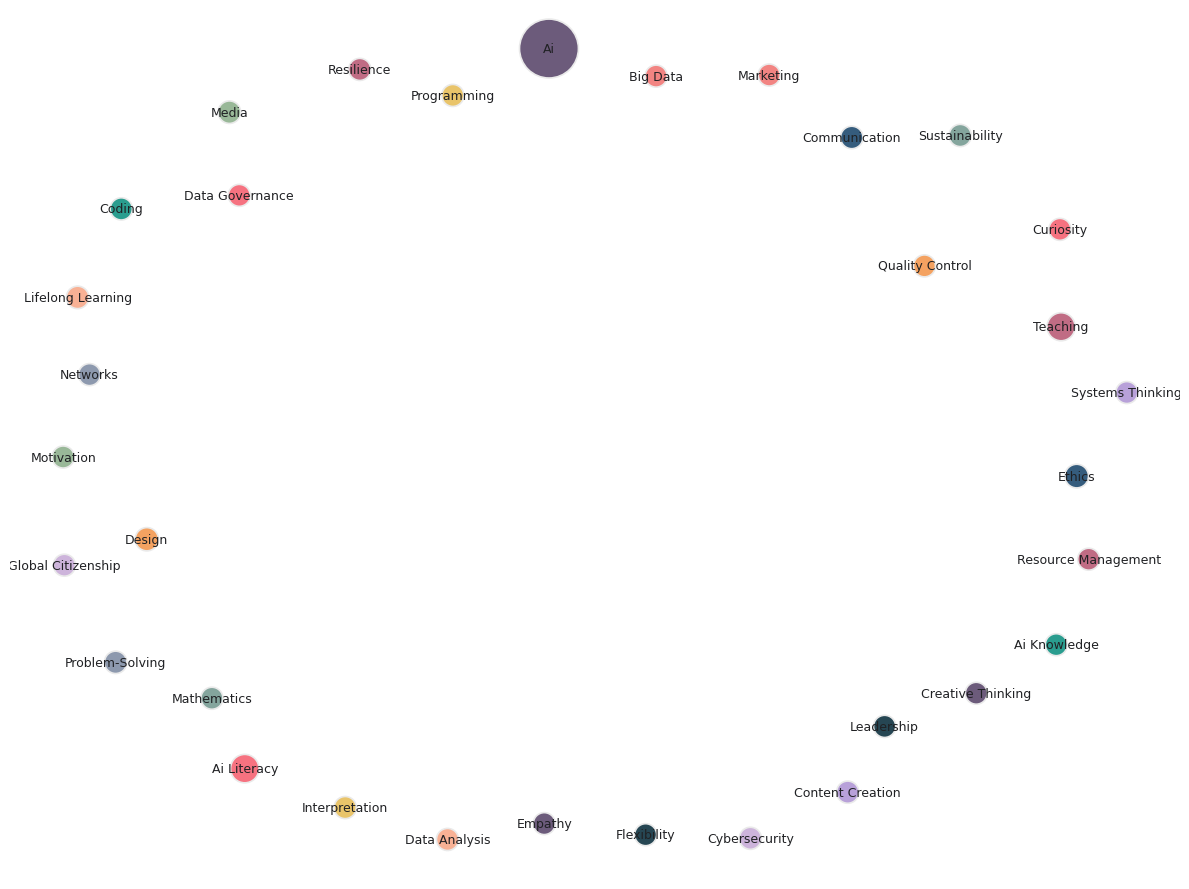

In [ ]:
import math
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# --- yardımcılar ---
def build_graph(nodes_list, edges_list):
    G = nx.Graph()
    for n in nodes_list:
        G.add_node(
            n['id'],
            label=n.get('label', n['id']),
            size=n.get('size', 10),
            title=n.get('title', '')
        )
    for e in edges_list:
        G.add_edge(
            e['from'], e['to'],
            weight=e.get('width', 1),
            title=e.get('title', '')
        )
    return G

def mentions_from_title(title):
    # "Mentions: X" formatından X'i alır; yoksa 1 kabul
    if "Mentions:" in title:
        try:
            return int(title.split(":")[-1].strip())
        except:
            return 1
    return 1

def scale(values, out_min=8, out_max=38):
    if not values:
        return []
    vmin, vmax = min(values), max(values)
    if vmin == vmax:
        return [ (out_min+out_max)/2 for _ in values ]
    return [out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin) for v in values]

# --- topluluk (cluster) renkleme: greedy modularity ---
def communities_to_color_map(G):
    # toplulukları bul
    comms = list(nx.algorithms.community.greedy_modularity_communities(G))
    # her düğüm -> community id
    node2comm = {}
    for i, c in enumerate(comms):
        for n in c:
            node2comm[n] = i
    # estetik, mavi yerine yumuşak bir palet (manuel seçtik)
    base_colors = [
        "#6C5B7B", "#C06C84", "#F67280", "#F8B195", "#355C7D",
        "#99B898", "#2A9D8F", "#E9C46A", "#F4A261", "#264653",
        "#B8A1D9", "#84A59D", "#F28482", "#8D99AE", "#CDB4DB"
    ]
    # gerekirse döngü
    colors = {}
    for n in G.nodes():
        cid = node2comm.get(n, 0)
        colors[n] = base_colors[cid % len(base_colors)]
    return colors

def draw_pretty_network(nodes_list, edges_list, seed=42, k_factor=1.2, min_edge_width=0.8, max_edge_width=4.5):
    G = build_graph(nodes_list, edges_list)

    # yerleşim: k'yi biraz büyük tutmak düğümleri açar
    pos = nx.spring_layout(G, seed=seed, k=None)  # k=None -> otomatik; aşağıda ölçekleyeceğiz
    # spring_layout "k" doğrudan büyütülmek istenirse tekrar çağırılabilir:
    # pos = nx.spring_layout(G, seed=seed, k=k_factor * (1 / math.sqrt(G.number_of_nodes()+1)))

    # node size: elindeki 'size' verisini ölçekle (veya 'Mentions' sayısından türet)
    raw_sizes = []
    for n, data in G.nodes(data=True):
        if data.get('size'):
            raw_sizes.append(data['size'])
        else:
            raw_sizes.append(10 + 5 * mentions_from_title(data.get('title', '')))
    node_sizes = scale(raw_sizes, out_min=250, out_max=1800)  # matplotlib piksel alanı

    # edge width: weight (width) => normalize
    raw_weights = []
    for u, v, ed in G.edges(data=True):
        raw_weights.append(ed.get('weight', 1))
    edge_widths = scale(raw_weights, out_min=min_edge_width, out_max=max_edge_width) if raw_weights else []

    # renk: topluluklara göre
    node_colors_map = communities_to_color_map(G)
    node_colors = [node_colors_map[n] for n in G.nodes()]

    plt.figure(figsize=(12, 9))

    # kenarlar: gri, hafif şeffaf; önce kenarları çiz ki düğümlerin altında kalsınlar
    nx.draw_networkx_edges(
        G, pos,
        width=edge_widths if edge_widths else 1.0,
        edge_color="#9AA0A6",
        alpha=0.55
    )

    # düğümler: topluluk rengine göre, kenarlık açık gri
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        linewidths=1.2,
        edgecolors="#EAEAEA"
    )

    # etiketler: okunaklı ve hafif
    nx.draw_networkx_labels(
        G, pos,
        labels={n: G.nodes[n].get('label', n) for n in G.nodes()},
        font_size=9,
        font_color="#202124"
    )

    plt.margins(0.05)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- çiz ---
draw_pretty_network(nodes_data_risk, edges_data_risk, seed=42, k_factor=1.2)


In [ ]:
# Colab / Jupyter için:
# !pip install -q sentence-transformers networkx


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- Top Semantic Similarities (first 20) ---


,Risk 1,Risk 2,Cosine Similarity
819,Precision,Attention to Detail,0.844339
387,Writing,Reading,0.693643
219,Design,Creative Thinking,0.686883
123,Motivation,Endurance,0.661601
435,Flexibility,Agility,0.659727
638,Operations,Resource Management,0.655482
747,Analytical Thinking,Systems Thinking,0.633075
111,Motivation,Agility,0.624739
657,User Experience,Technological Literacy,0.621324
783,Customer Service,Service Orientation,0.615395


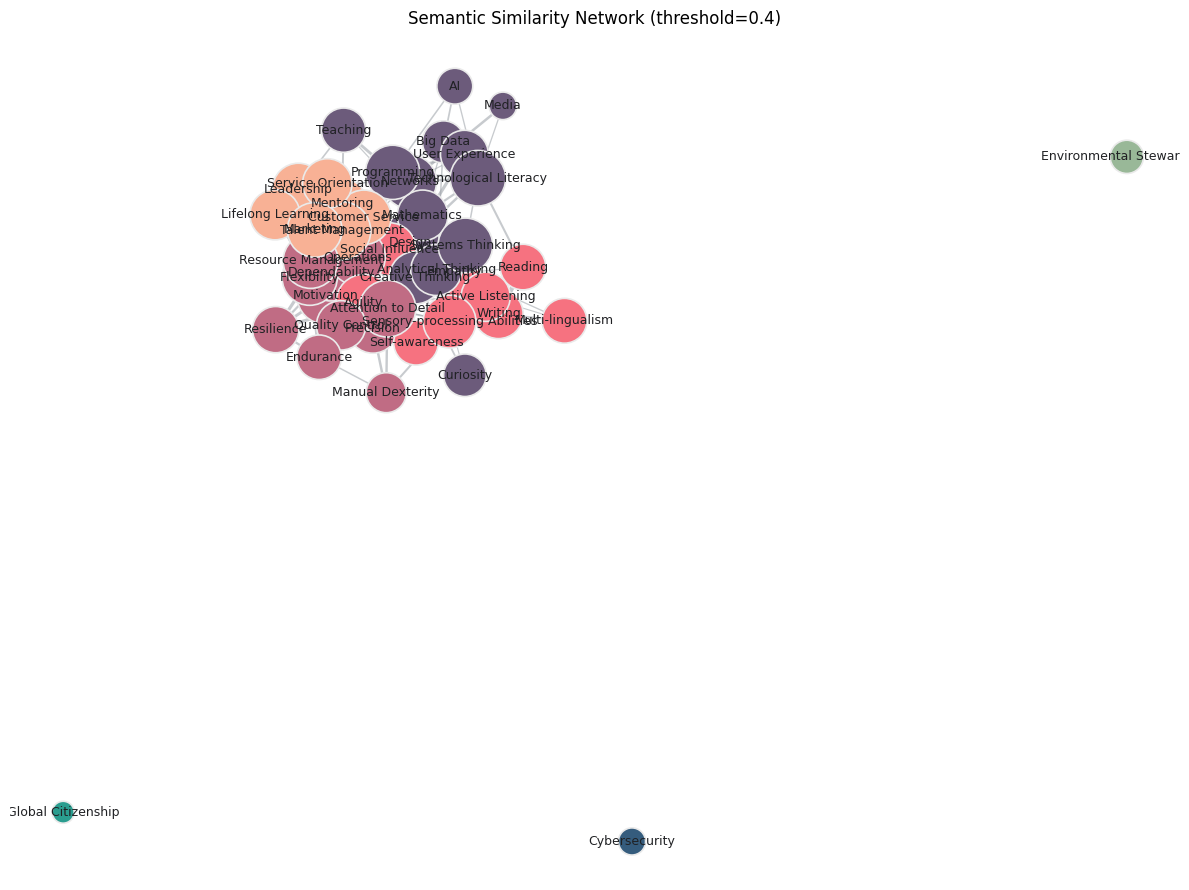

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# RİSK LİSTEN (senin mevcut listen)
# -----------------------------
custom_risks = [
    "AI", "Teaching", "Motivation", "Big Data", "Dependability", "Design", "Media",
    "Networks", "Mathematics", "Cybersecurity", "Writing", "Flexibility", "Social Influence",
    "Reading", "Multi-lingualism", "Curiosity", "Leadership", "Empathy", "Operations",
    "User Experience", "Creative Thinking", "Mentoring", "Programming", "Analytical Thinking",
    "Lifelong Learning", "Customer Service", "Manual Dexterity", "Precision", "Resilience",
    "Agility", "Self-awareness", "Technological Literacy", "Active Listening", "Talent Management",
    "Service Orientation", "Systems Thinking", "Resource Management", "Attention to Detail",
    "Quality Control", "Marketing", "Environmental Stewardship", "Endurance", "Global Citizenship",
    "Sensory-processing Abilities"
]

# -----------------------------
# (Opsiyonel) Kısa terimlere bağlam ekleme
# -----------------------------
# Kısa/soyut etiketler (AI, Design…) bazen zayıf embedding üretir.
# Bu sözlükle her etikete kısa bir bağlam ekleyebilirsin. Gerekirse çoğalt.
context_boost = {
    "AI": "Artificial intelligence in higher education policy and curriculum",
    "Teaching": "Teaching and pedagogy in university courses",
    "Motivation": "Ability to sustain effort, set goals, and engage in tasks with persistence",
    "Big Data": "Big data analytics and data-driven decision making in education",
    "Dependability": "Reliability and consistency in fulfilling responsibilities",
    "Design": "Creativity and technical ability to develop functional and user-centered solutions",
    "Media": "Understanding and use of mass, digital, and social media platforms",
    "Networks": "Ability to build and leverage professional, social, or digital networks",
    "Mathematics": "Mathematics skills and quantitative reasoning in curricula",
    "Cybersecurity": "Cybersecurity risks and data protection in universities",
    "Writing": "Ability to produce clear, coherent, and impactful written communication",
    "Flexibility": "Capacity to adapt to new conditions, roles, or technologies",
    "Social Influence": "Skills in persuading, negotiating, and shaping others’ attitudes and behaviors",
    "Reading": "Ability to comprehend, interpret, and critically engage with written texts",
    "Multi-lingualism": "Proficiency in communicating effectively in multiple languages",
    "Curiosity": "Disposition to explore, inquire, and seek new knowledge",
    "Leadership": "Leadership competencies in academic and organizational settings",
    "Empathy": "Empathy and interpersonal skills in communication and teamwork",
    "Operations": "Skills in managing processes, logistics, and systems for efficiency",
    "User Experience": "User experience design and usability in digital learning tools",
    "Creative Thinking": "Ability to generate novel, original, and valuable ideas or solutions",
    "Mentoring": "Skills in supporting, coaching, and guiding the development of others",
    "Programming": "Programming skills and software development in education",
    "Analytical Thinking": "Ability to analyze complex problems, interpret data, and draw conclusions",
    "Lifelong Learning": "Commitment to continuously updating skills and knowledge across life",
    "Customer Service": "Competence in meeting client needs and maintaining relationships",
    "Manual Dexterity": "Physical skill in performing precise movements with hand–eye coordination",
    "Precision": "Attention to accuracy and exactness in performing tasks",
    "Resilience": "Capacity to recover quickly from difficulties and maintain effectiveness",
    "Agility": "Ability to respond quickly and effectively to changes in environment or goals",
    "Self-awareness": "Insight into one’s own emotions, strengths, and impact on others",
    "Technological Literacy": "Competence in using and critically evaluating digital tools and systems",
    "Active Listening": "Ability to attentively hear, understand, and respond appropriately to others",
    "Talent Management": "Skills in attracting, developing, and retaining skilled individuals",
    "Service Orientation": "Commitment to helping others and anticipating stakeholder needs",
    "Systems Thinking": "Ability to perceive, analyze, and manage interdependent systems",
    "Resource Management": "Skills in allocating time, money, and materials efficiently",
    "Attention to Detail": "Accuracy and thoroughness in completing tasks",
    "Quality Control": "Ability to monitor and assess work outputs for improvement",
    "Marketing": "Competence in promoting ideas, products, or services strategically",
    "Environmental Stewardship": "Responsibility for conserving natural resources sustainably",
    "Endurance": "Physical and mental stamina to perform tasks over time",
    "Global Citizenship": "Awareness of global issues and commitment to inclusive engagement",
    "Sensory-processing Abilities": "Capacity to receive, interpret, and respond to sensory information"

}

def label_with_context(label: str) -> str:
    # Çok dilli gömmelerde kısa label + kısa açıklama iyi sonuç verir
    if label in context_boost:
        return f"{label}. {context_boost[label]}"
    return label

labels_for_embedding = [label_with_context(x) for x in custom_risks]

# -----------------------------
# MODEL ve EMBEDDING
# -----------------------------
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)

embeddings = model.encode(labels_for_embedding, normalize_embeddings=True)  # (N, d)
# normalize=True -> cosine ~ dot product, stabilite

# -----------------------------
# COSINE SIMILARITY MATRİSİ
# -----------------------------
sim = cosine_similarity(embeddings)  # (N, N), 0..1 arası

# -----------------------------
# EN BENZER ÇİFTLER TABLOSU
# -----------------------------
pairs = []
n = len(custom_risks)
for i in range(n):
    for j in range(i+1, n):
        pairs.append({
            "Risk 1": custom_risks[i],
            "Risk 2": custom_risks[j],
            "Cosine Similarity": float(sim[i, j])
        })

df_sim = pd.DataFrame(pairs).sort_values("Cosine Similarity", ascending=False)

print("\n--- Top Semantic Similarities (first 20) ---")
display(df_sim.head(20))  # Jupyter/Colab için; plain Python'da print(df_sim.head(20))

# -----------------------------
# ANLAMSAL AĞ: EŞİKLEME
# -----------------------------
SIM_THRESHOLD = 0.40  # başlangıç için 0.40-0.55 arası dene; fazla/az bağlantıya göre ayarla

edges = []
for i in range(n):
    for j in range(i+1, n):
        if sim[i, j] >= SIM_THRESHOLD:
            edges.append((custom_risks[i], custom_risks[j], sim[i, j]))

# Düğüm boyutu: "anlamsal merkezilik" basit proxy'si olarak derece veya toplam benzerlik
node_strength = {custom_risks[i]: float(np.sum(sim[i])) for i in range(n)}

# -----------------------------
# GRAF OLUŞTURMA ve ÇİZİM
# -----------------------------
G = nx.Graph()
# düğümler
for label in custom_risks:
    G.add_node(label, strength=node_strength[label])

# kenarlar
for a, b, w in edges:
    G.add_edge(a, b, weight=w)

# renkleri kümelere göre (varsa) ata
if G.number_of_edges() > 0:
    comms = list(nx.algorithms.community.greedy_modularity_communities(G))
    pal = ["#6C5B7B","#C06C84","#F67280","#F8B195","#355C7D","#99B898","#2A9D8F","#E9C46A","#F4A261","#264653"]
    color_map = {}
    for ci, cset in enumerate(comms):
        for node in cset:
            color_map[node] = pal[ci % len(pal)]
else:
    color_map = {node: "#6C5B7B" for node in G.nodes()}

# konum
pos = nx.spring_layout(G, seed=42)

# boyut ve kenar kalınlığı ölçekleme
def scale(values, out_min=8, out_max=36):
    vals = list(values)
    if not vals:
        return []
    vmin, vmax = min(vals), max(vals)
    if vmin == vmax:
        return [(out_min + out_max)/2 for _ in vals]
    return [out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin) for v in vals]

node_sizes = scale([G.nodes[n]["strength"] for n in G.nodes()], 250, 1800)
edge_widths = scale([G[u][v]["weight"] for u, v in G.edges()], 0.8, 4.5)

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="#9AA0A6", alpha=0.55)
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=[color_map[n] for n in G.nodes()],
    linewidths=1.2, edgecolors="#EAEAEA"
)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="#202124")
plt.title(f"Semantic Similarity Network (threshold={SIM_THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
!pip install pyvis

In [ ]:
# --- Semantic Closeness Network for nodes_data_risk (PyVis) --- YENI
# Requirements: sentence-transformers, scikit-learn, pyvis
# If needed: pip install sentence-transformers scikit-learn pyvis

import re
import json
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from pyvis.network import Network

# ---------------------------------------------------------------------
# 0) EXPECTED INPUT: nodes_data_risk from your earlier pipeline
#    nodes_data_risk = [{'id': label, 'label': label, 'size': 10+5*cnt, 'title': 'Mentions: N'}, ...]
# ---------------------------------------------------------------------
try:
    _ = nodes_data_risk  # just to assert it exists
except NameError:
    raise NameError("nodes_data_risk is not defined. Run the earlier extraction code first.")

# ---------------------------------------------------------------------
# 1) CATEGORY DEFINITIONS (same as your earlier 'skills' list)
#    -> used to color nodes by category
# ---------------------------------------------------------------------
skills = [
    {"category": "Cognitive Skills", "skills": [
        "Analytical thinking","Creative thinking","Systems thinking","Multilingualism",
        "Reading & writing","Mathematics","Mathematical infrastructure",
        "Mathematical modeling","Mathematical instructions"
    ]},
    {"category": "Self-efficacy Skills", "skills": [
        "Resilience","Flexibility","Agility","Motivation","Self-awareness","Curiosity",
        "Lifelong learning","Dependability","Attention to detail"
    ]},
    {"category": "Working with Others", "skills": [
        "Leadership","Social influence","Empathy","Active listening","Teaching","Mentoring"
    ]},
    {"category": "Technology Skills", "skills": [
        "Technological literacy","AI","AI literacy","AI knowledge","Big Data","Data analysis",
        "Interpretation","Data governance","Networks","Network administration","Cybersecurity",
        "Design","User experience","Programming","Coding","Software development"
    ]},
    {"category": "Management Skills", "skills": [
        "Talent management","Resource management","Operations management","Quality control"
    ]},
    {"category": "Engagement Skills", "skills": [
        "Service orientation","Customer service","Communication","Conflict resolution",
        "Problem-solving","Marketing & media","Marketing","Media","Digital communication",
        "Content creation","Persuasion","Environmental stewardship","Sustainability",
        "Global citizenship","Cultural awareness","Ethics","Civic responsibility"
    ]},
    {"category": "Physical Abilities", "skills": [
        "Manual dexterity","Endurance","Precision","Sensory-processing abilities"
    ]}
]

# Build label -> category map (case/punctuation tolerant)
def norm(s: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w&+\- ]", " ", s.lower())).strip()

label2cat = {}
for block in skills:
    cat = block["category"]
    for s in block["skills"]:
        label2cat[norm(s)] = cat

# ---------------------------------------------------------------------
# 2) CONTEXT BOOST (improves embeddings for short labels like "AI")
# ---------------------------------------------------------------------
context_boost = {
    "AI": "Artificial intelligence in higher education policy and curriculum",
    "Teaching": "Teaching and pedagogy in university courses",
    "Motivation": "Ability to sustain effort and engage with persistence",
    "Big Data": "Big data analytics and data-driven decision making",
    "Dependability": "Reliability and consistency in fulfilling responsibilities",
    "Design": "User-centered design and functional solution development",
    "Media": "Use of mass, digital, and social media platforms",
    "Networks": "Professional and digital networking capabilities",
    "Mathematics": "Quantitative reasoning and mathematical skills",
    "Cybersecurity": "Cybersecurity risks and data protection",
    "Writing": "Clear and impactful written communication",
    "Flexibility": "Adaptation to new conditions and technologies",
    "Social influence": "Persuasion, negotiation, and shaping attitudes",
    "Reading": "Comprehension and critical engagement with texts",
    "Multilingualism": "Proficiency in multiple languages",
    "Curiosity": "Inquiry and desire to seek new knowledge",
    "Leadership": "Leading teams in academic/organizational settings",
    "Empathy": "Interpersonal understanding in teamwork",
    "Operations management": "Managing processes and systems efficiently",
    "User experience": "UX design and usability in digital tools",
    "Creative thinking": "Generating original valuable ideas and solutions",
    "Mentoring": "Coaching and guiding others' development",
    "Programming": "Coding and software development skills",
    "Analytical thinking": "Analyzing complex problems and data",
    "Lifelong learning": "Continual skills/knowledge development",
    "Customer service": "Meeting client needs and relationships",
    "Manual dexterity": "Precise hand–eye coordination",
    "Precision": "Accuracy and exactness in tasks",
    "Resilience": "Recovering quickly from difficulties",
    "Agility": "Responding quickly to change",
    "Self-awareness": "Insight into one’s emotions and strengths",
    "Technological literacy": "Using and evaluating digital tools",
    "Active listening": "Attentively understanding and responding",
    "Talent management": "Attracting and developing people",
    "Service orientation": "Helping others and anticipating needs",
    "Systems thinking": "Understanding interdependent systems",
    "Resource management": "Allocating time, money, materials",
    "Attention to detail": "Accuracy and thoroughness",
    "Quality control": "Monitoring outputs for improvement",
    "Marketing": "Promoting ideas, products, or services",
    "Environmental stewardship": "Conserving natural resources",
    "Endurance": "Sustained physical/mental effort",
    "Global citizenship": "Awareness of global issues",
    "Sensory-processing abilities": "Interpreting sensory information",
}

def label_with_context(label: str) -> str:
    # Use the exact label casing for matching the boost; fallback to a case-insensitive hit
    if label in context_boost:
        return f"{label}. {context_boost[label]}"
    # try case-insensitive keys
    for k in context_boost.keys():
        if k.lower() == label.lower():
            return f"{label}. {context_boost[k]}"
    return label

# ---------------------------------------------------------------------
# 3) COLLECT ACTIVE LABELS (those that actually occurred in the doc)
#    We'll read from nodes_data_risk to honor your earlier extraction.
#    We also parse mention counts from the 'title' ("Mentions: N").
# ---------------------------------------------------------------------
labels = []
mentions = {}
for n in nodes_data_risk:
    lbl = str(n.get("id") or n.get("label"))
    if not lbl:
        continue
    labels.append(lbl)
    # parse mentions from "Mentions: N", robust fallback = 1
    mt = n.get("title", "")
    m = re.search(r"(\d+)", str(mt))
    mentions[lbl] = int(m.group(1)) if m else 1

labels = sorted(set(labels))  # unique & stable order

# ---------------------------------------------------------------------
# 4) EMBEDDINGS & SIMILARITY
# ---------------------------------------------------------------------
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)
texts_for_embed = [label_with_context(x) for x in labels]
emb = model.encode(texts_for_embed, normalize_embeddings=True)
sim = cosine_similarity(emb)
np.fill_diagonal(sim, 0.0)  # don't let self-similarity bias strengths

# ---------------------------------------------------------------------
# 5) GRAPH EDGES (top-k per node + minimum threshold)
# ---------------------------------------------------------------------
TOPK = 4          # keep strongest 4 neighbors per node
MIN_SIM = 0.25    # also require similarity >= this
edges = set()
for i in range(len(labels)):
    # get top-k indices
    idxs = np.argsort(sim[i])[-TOPK:]
    for j in idxs:
        if sim[i, j] >= MIN_SIM:
            a, b = (labels[i], labels[j]) if i < j else (labels[j], labels[i])
            if a != b:
                edges.add((a, b, float(sim[i, j])))
edges = list(edges)

# Node strength: sum of drawn edge weights (matches visualization)
strength = {lbl: 0.0 for lbl in labels}
for a, b, w in edges:
    strength[a] += w
    strength[b] += w

# ---------------------------------------------------------------------
# 6) CATEGORY COLORS
# ---------------------------------------------------------------------
category_palette = {
    "Cognitive Skills":         "#355C7D",
    "Self-efficacy Skills":     "#C06C84",
    "Working with Others":      "#F67280",
    "Technology Skills":        "#99B898",
    "Management Skills":        "#2A9D8F",
    "Engagement Skills":        "#E9C46A",
    "Physical Abilities":       "#F4A261",
    "Unknown":                  "#6C5B7B",
}

def category_of(label: str) -> str:
    return label2cat.get(norm(label), "Unknown")

def color_of(label: str) -> str:
    return category_palette.get(category_of(label), category_palette["Unknown"])

# ---------------------------------------------------------------------
# 7) SCALE HELPERS (for node sizes and edge widths)
# ---------------------------------------------------------------------
def scale(values, out_min, out_max):
    if not values:
        return []
    vmin, vmax = min(values), max(values)
    if vmin == vmax:
        return [ (out_min + out_max) / 2.0 for _ in values ]
    return [ out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin) for v in values ]

# Node size uses a blend: mentions and strength (feel free to tweak weights)
mention_vals  = [mentions[lbl] for lbl in labels]
strength_vals = [strength[lbl] for lbl in labels]
m_scaled = scale(mention_vals, 12, 28)
s_scaled = scale(strength_vals, 8, 26)
node_sizes = {lbl: (0.6*m + 0.4*s) for lbl, m, s in zip(labels, m_scaled, s_scaled)}

if edges:
    w_vals = [w for _, _, w in edges]
    edge_widths = dict(((a, b), w) for a, b, w in zip(
        [e[0] for e in edges],
        [e[1] for e in edges],
        scale(w_vals, 1.0, 6.5)
    ))
else:
    edge_widths = {}

# ---------------------------------------------------------------------
# 8) BUILD PYVIS NETWORK
# ---------------------------------------------------------------------
net = Network(height="720px", width="100%", bgcolor="#FFFFFF",
              cdn_resources="in_line", notebook=True, directed=False)
net.barnes_hut(gravity=-23000, central_gravity=0.12, spring_length=160, spring_strength=0.01,
               damping=0.9, overlap=0.1)

# Add nodes
for lbl in labels:
    cat = category_of(lbl)
    title = (
        f"<b>{lbl}</b><br>"
        f"Category: {cat}<br>"
        f"Mentions: {mentions[lbl]}<br>"
        f"Strength: {strength[lbl]:.3f}"
    )
    net.add_node(
        lbl,
        label=lbl,
        title=title,
        size=float(node_sizes[lbl]) * 2.2,  # pyvis sizes feel smaller; upscale a bit
        color=color_of(lbl),
        borderWidth=1
    )

# Add edges
for a, b, w in edges:
    net.add_edge(a, b, value=float(w), title=f"Cosine similarity: {w:.3f}",
                 width=float(edge_widths.get((a, b), 2.0)), color="#9AA0A6", physics=True, smooth=True)

# Gentle physics and clean interaction
net.set_options(json.dumps({
    "interaction": {
        "hover": True,
        "dragNodes": True,
        "multiselect": True,
        "zoomView": True
    },
    "physics": {
        "enabled": True,
        "stabilization": {"enabled": True, "iterations": 200},
        "solver": "forceAtlas2Based",
        "forceAtlas2Based": {"gravitationalConstant": -35, "springConstant": 0.06, "springLength": 110},
        "minVelocity": 0.75,
        "timestep": 0.30,
        "maxVelocity": 30
    },
    "edges": {
        "smooth": {"type": "dynamic"},
        "color": {"inherit": False}
    },
    "nodes": {
        "font": {"size": 16, "face": "Arial", "color": "#202124"},
        "shape": "dot",
        "borderWidth": 1
    }
}))

# Save & show
html_path = "semantic_risk_network.html"
net.show(html_path)   # In notebooks: renders inline. Else, open the generated HTML file.
print(f"Graph saved to: {html_path}")


semantic_risk_network.html
Graph saved to: semantic_risk_network.html


In [ ]:
# --- Semantic Closeness Network for nodes_data_risk (PyVis) --- YENI
# Requirements: sentence-transformers, scikit-learn, pyvis
# If needed: pip install sentence-transformers scikit-learn pyvis

import re
import json
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from pyvis.network import Network

# ---------------------------------------------------------------------
# 0) EXPECTED INPUT: nodes_data_risk from your earlier pipeline
#    nodes_data_risk = [{'id': label, 'label': label, 'size': 10+5*cnt, 'title': 'Mentions: N'}, ...]
# ---------------------------------------------------------------------
try:
    _ = nodes_data_risk  # just to assert it exists
except NameError:
    raise NameError("nodes_data_risk is not defined. Run the earlier extraction code first.")

# ---------------------------------------------------------------------
# 1) CATEGORY DEFINITIONS (same as your earlier 'skills' list)
#    -> used to color nodes by category
# ---------------------------------------------------------------------
skills = [
    {"category": "Cognitive Skills", "skills": [
        "Analytical thinking","Creative thinking","Systems thinking","Multilingualism",
        "Reading & writing","Mathematics"
    ]},
    {"category": "Self-efficacy Skills", "skills": [
        "Resilience","Flexibility","Agility","Motivation","Self-awareness","Curiosity",
        "Lifelong learning","Dependability","Attention to detail", "global citizenship"
    ]},
    {"category": "Working with Others", "skills": [
        "Leadership","Social influence","Empathy","Active listening","Teaching","Mentoring"
    ]},
    {"category": "Technology Skills", "skills": [
        "Technological literacy","AI","AI literacy","AI knowledge","Big Data","Data analysis",
        "Interpretation","Data governance","Networks","Network administration","Cybersecurity",
        "Design","User experience","Programming","Coding","Software development"
    ]},
    {"category": "Management Skills", "skills": [
        "Talent management","Resource management","Operations management","Quality control"
    ]},
    {"category": "Engagement Skills", "skills": [
        "Service orientation","Customer service","Communication","Conflict resolution",
        "Problem-solving","Marketing & media","Marketing","Media","Digital communication",
        "Content creation","Persuasion","Environmental stewardship","Sustainability","Cultural awareness","Ethics","Civic responsibility"
    ]},
    {"category": "Physical Abilities", "skills": [
        "Manual dexterity","Endurance","Precision","Sensory-processing abilities"
    ]}
]

# Build label -> category map (case/punctuation tolerant)
def norm(s: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w&+\- ]", " ", s.lower())).strip()

label2cat = {}
for block in skills:
    cat = block["category"]
    for s in block["skills"]:
        label2cat[norm(s)] = cat

# ---------------------------------------------------------------------
# 2) CONTEXT BOOST (improves embeddings for short labels like "AI")
# ---------------------------------------------------------------------
context_boost = {
    "AI": "Artificial intelligence in higher education policy and curriculum",
    "Teaching": "Teaching and pedagogy in university courses",
    "Motivation": "Ability to sustain effort and engage with persistence",
    "Big Data": "Big data analytics and data-driven decision making",
    "Dependability": "Reliability and consistency in fulfilling responsibilities",
    "Design": "User-centered design and functional solution development",
    "Media": "Use of mass, digital, and social media platforms",
    "Networks": "Professional and digital networking capabilities",
    "Mathematics": "Quantitative reasoning and mathematical skills",
    "Cybersecurity": "Cybersecurity risks and data protection",
    "Writing": "Clear and impactful written communication",
    "Flexibility": "Adaptation to new conditions and technologies",
    "Social influence": "Persuasion, negotiation, and shaping attitudes",
    "Reading": "Comprehension and critical engagement with texts",
    "Multilingualism": "Proficiency in multiple languages",
    "Curiosity": "Inquiry and desire to seek new knowledge",
    "Leadership": "Leading teams in academic/organizational settings",
    "Empathy": "Interpersonal understanding in teamwork",
    "Operations management": "Managing processes and systems efficiently",
    "User experience": "UX design and usability in digital tools",
    "Creative thinking": "Generating original valuable ideas and solutions",
    "Mentoring": "Coaching and guiding others' development",
    "Programming": "Coding and software development skills",
    "Analytical thinking": "Analyzing complex problems and data",
    "Lifelong learning": "Continual skills/knowledge development",
    "Customer service": "Meeting client needs and relationships",
    "Manual dexterity": "Precise hand–eye coordination",
    "Precision": "Accuracy and exactness in tasks",
    "Resilience": "Recovering quickly from difficulties",
    "Agility": "Responding quickly to change",
    "Self-awareness": "Insight into one’s emotions and strengths",
    "Technological literacy": "Using and evaluating digital tools",
    "Active listening": "Attentively understanding and responding",
    "Talent management": "Attracting and developing people",
    "Service orientation": "Helping others and anticipating needs",
    "Systems thinking": "Understanding interdependent systems",
    "Resource management": "Allocating time, money, materials",
    "Attention to detail": "Accuracy and thoroughness",
    "Quality control": "Monitoring outputs for improvement",
    "Marketing": "Promoting ideas, products, or services",
    "Environmental stewardship": "Conserving natural resources",
    "Endurance": "Sustained physical/mental effort",
    "Global citizenship": "Awareness of global issues",
    "Sensory-processing abilities": "Interpreting sensory information",
}

def label_with_context(label: str) -> str:
    # Use the exact label casing for matching the boost; fallback to a case-insensitive hit
    if label in context_boost:
        return f"{label}. {context_boost[label]}"
    # try case-insensitive keys
    for k in context_boost.keys():
        if k.lower() == label.lower():
            return f"{label}. {context_boost[k]}"
    return label

# ---------------------------------------------------------------------
# 3) COLLECT ACTIVE LABELS (those that actually occurred in the doc)
#    We'll read from nodes_data_risk to honor your earlier extraction.
#    We also parse mention counts from the 'title' ("Mentions: N").
# ---------------------------------------------------------------------
labels = []
mentions = {}
for n in nodes_data_risk:
    lbl = str(n.get("id") or n.get("label"))
    if not lbl:
        continue
    labels.append(lbl)
    # parse mentions from "Mentions: N", robust fallback = 1
    mt = n.get("title", "")
    m = re.search(r"(\d+)", str(mt))
    mentions[lbl] = int(m.group(1)) if m else 1

labels = sorted(set(labels))  # unique & stable order

# ---------------------------------------------------------------------
# 4) EMBEDDINGS & SIMILARITY
# ---------------------------------------------------------------------
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)
texts_for_embed = [label_with_context(x) for x in labels]
emb = model.encode(texts_for_embed, normalize_embeddings=True)
sim = cosine_similarity(emb)
np.fill_diagonal(sim, 0.0)  # don't let self-similarity bias strengths

# ---------------------------------------------------------------------
# 5) GRAPH EDGES (top-k per node + minimum threshold)
# ---------------------------------------------------------------------
TOPK = 4          # keep strongest 4 neighbors per node
MIN_SIM = 0.25    # also require similarity >= this
edges = set()
for i in range(len(labels)):
    # get top-k indices
    idxs = np.argsort(sim[i])[-TOPK:]
    for j in idxs:
        if sim[i, j] >= MIN_SIM:
            a, b = (labels[i], labels[j]) if i < j else (labels[j], labels[i])
            if a != b:
                edges.add((a, b, float(sim[i, j])))
edges = list(edges)

# Node strength: sum of drawn edge weights (matches visualization)
strength = {lbl: 0.0 for lbl in labels}
for a, b, w in edges:
    strength[a] += w
    strength[b] += w

# ---------------------------------------------------------------------
# 6) CATEGORY COLORS
# ---------------------------------------------------------------------
category_palette = {
    "Cognitive Skills":         "#355C7D",
    "Self-efficacy Skills":     "#C06C84",
    "Working with Others":      "#F67280",
    "Technology Skills":        "#99B898",
    "Management Skills":        "#2A9D8F",
    "Engagement Skills":        "#E9C46A",
    "Physical Abilities":       "#F4A261",
    "Unknown":                  "#6C5B7B",
}

def category_of(label: str) -> str:
    return label2cat.get(norm(label), "Unknown")

def color_of(label: str) -> str:
    return category_palette.get(category_of(label), category_palette["Unknown"])

# ---------------------------------------------------------------------
# 7) SCALE HELPERS (for node sizes and edge widths)
# ---------------------------------------------------------------------
def scale(values, out_min, out_max):
    if not values:
        return []
    vmin, vmax = min(values), max(values)
    if vmin == vmax:
        return [ (out_min + out_max) / 2.0 for _ in values ]
    return [ out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin) for v in values ]

# Node size uses a blend: mentions and strength (feel free to tweak weights)
mention_vals  = [mentions[lbl] for lbl in labels]
strength_vals = [strength[lbl] for lbl in labels]
m_scaled = scale(mention_vals, 12, 28)
s_scaled = scale(strength_vals, 8, 26)
node_sizes = {lbl: (0.6*m + 0.4*s) for lbl, m, s in zip(labels, m_scaled, s_scaled)}

if edges:
    w_vals = [w for _, _, w in edges]
    edge_widths = dict(((a, b), w) for a, b, w in zip(
        [e[0] for e in edges],
        [e[1] for e in edges],
        scale(w_vals, 1.0, 6.5)
    ))
else:
    edge_widths = {}

# ---------------------------------------------------------------------
# 8) BUILD PYVIS NETWORK
# ---------------------------------------------------------------------
net = Network(height="720px", width="100%", bgcolor="#FFFFFF",
              cdn_resources="in_line", notebook=True, directed=False)
net.barnes_hut(gravity=-23000, central_gravity=0.12, spring_length=160, spring_strength=0.01,
               damping=0.9, overlap=0.1)

# Add nodes
for lbl in labels:
    cat = category_of(lbl)
    title = (
        f"<b>{lbl}</b><br>"
        f"Category: {cat}<br>"
        f"Mentions: {mentions[lbl]}<br>"
        f"Strength: {strength[lbl]:.3f}"
    )
    net.add_node(
        lbl,
        label=lbl,
        title=title,
        size=float(node_sizes[lbl]) * 2.2,  # pyvis sizes feel smaller; upscale a bit
        color=color_of(lbl),
        borderWidth=1,
        font={"size": 28}
    )

# Add edges
for a, b, w in edges:
    net.add_edge(a, b, value=float(w), title=f"Cosine similarity: {w:.3f}",
                 width=float(edge_widths.get((a, b), 2.0)), color="#9AA0A6", physics=True, smooth=True)

# Gentle physics and clean interaction
net.set_options(json.dumps({
    "interaction": {
        "hover": True,
        "dragNodes": True,
        "multiselect": True,
        "zoomView": True
    },
    "physics": {
        "enabled": True,
        "stabilization": {"enabled": True, "iterations": 200},
        "solver": "forceAtlas2Based",
        "forceAtlas2Based": {"gravitationalConstant": -35, "springConstant": 0.06, "springLength": 110},
        "minVelocity": 0.75,
        "timestep": 0.30,
        "maxVelocity": 30
    },
    "edges": {
        "smooth": {"type": "dynamic"},
        "color": {"inherit": False}
    },
    "nodes": {
        "font": {"size": 16, "face": "Arial", "color": "#202124"},
        "shape": "dot",
        "borderWidth": 1
    }
}))

# Save & show
html_path = "semantic_risk_network.html"
net.show(html_path)   # In notebooks: renders inline. Else, open the generated HTML file.
print(f"Graph saved to: {html_path}")


semantic_risk_network.html
Graph saved to: semantic_risk_network.html


In [ ]:
from google.colab import files
files.download("semantic_risk_network.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- Define combine_skills if it's missing (safe to run multiple times) ---
try:
    combine_skills  # already defined?
except NameError:
    import re
    from collections import Counter

    # Fallback helpers only used if your originals aren't defined
    try:
        canonical
    except NameError:
        def canonical(s: str) -> str:
            return re.sub(r"\s+", " ",
                          re.sub(r"[^\w&+\- ]", " ", str(s).lower())
                         ).replace(" and ", " & ").strip()

    try:
        category_of
    except NameError:
        def category_of(label: str) -> str:
            try:
                return label2cat.get(canonical(label), "Unknown")
            except NameError:
                return "Unknown"

    try:
        label2cat
    except NameError:
        label2cat = {}

    def _parse_mentions_from_title(title: str, default: int = 1) -> int:
        m = re.search(r"(\d+)", str(title))
        return int(m.group(1)) if m else default

    def combine_skills(nodes, groups, separator=" + "):
        """
        Merge specified skills into single nodes with concatenated labels.
        - Sums 'Mentions' from node['title'].
        - Removes original nodes.
        - Assigns category (explicit > majority > 'Unknown') and updates label2cat.
        """
        # index nodes by canonical label
        by_norm = {}
        for n in nodes:
            lbl = str(n.get("id") or n.get("label") or "").strip()
            if not lbl:
                continue
            by_norm.setdefault(canonical(lbl), []).append(n)

        to_remove = set()
        new_nodes  = []

        for g in groups:
            skills_list = g.get("skills", [])
            if not skills_list:
                continue

            new_label = g.get("label") or separator.join(skills_list)

            # collect all nodes that match the skills to merge
            matched_nodes = []
            for s in skills_list:
                matched_nodes.extend(by_norm.get(canonical(s), []))

            if not matched_nodes:
                # nothing found to merge—skip quietly
                continue

            # aggregate mentions, track categories for majority vote
            total_mentions = 0
            cats = []
            for n in matched_nodes:
                total_mentions += _parse_mentions_from_title(n.get("title", ""), default=1)
                lbl = str(n.get("id") or n.get("label") or "")
                cats.append(category_of(lbl))
                to_remove.add(lbl)

            # decide category
            if g.get("category"):
                new_cat = g["category"]
            else:
                c = Counter([c for c in cats if c])
                new_cat = c.most_common(1)[0][0] if c else "Unknown"

            # ensure coloring works for the new label
            label2cat[canonical(new_label)] = new_cat

            # create the merged node (size will be rescaled later)
            new_nodes.append({
                "id": new_label,
                "label": new_label,
                "title": f"Mentions: {total_mentions}",
                "size": 10 + 5 * total_mentions
            })

        # rebuild nodes: keep non-removed originals, add merged ones
        kept, seen = [], set()
        for n in nodes:
            lbl = str(n.get("id") or n.get("label") or "")
            if lbl not in to_remove and lbl not in seen:
                kept.append(n); seen.add(lbl)

        return kept + new_nodes


In [ ]:
# Define your merge groups (edit as you like)
merge_groups = [
    {"skills": ["AI", "Big Data"], "label": "AI + Big Data", "category": "Technology Skills"},
    {"skills": ["Teaching", "Mentoring"], "label": "Teaching + Mentoring", "category": "Working with Others"},
]

# Merge and draw
merged_nodes, out_html = merge_and_draw(nodes_data_risk, merge_groups)


NameError: name 'merge_and_draw' is not defined